# CLASSIFYING NEWSWIRES: A MULTICLASSIFICATION EXAMPLE #

Dataset (Reuters dataset)

In [180]:
import random
import numpy as np
import tensorflow as tf
import os

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

In [181]:
from keras.datasets import reuters

(train_data, train_labels), (test_data, test_labels) = reuters.load_data(num_words = 20000)

In [182]:
unique_words = set(
    word
    for sequence in train_data
    for word in sequence
)

print("Number of unique words used:", len(unique_words))

Number of unique words used: 19369


In [183]:
# Decoding newswires back to text

word_index = reuters.get_word_index()
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])
decoded_newswire = ' '.join(
    [reverse_word_index.get(i - 3, '?') for i in train_data[10]]
)

Preparing the data

In [184]:
#Multi-hot encoding for data

def vectorize_sequences(sequences, dimension=20000):
    results = np.zeros((len(sequences), dimension))
    for i, seq in enumerate(sequences):
        results[i, seq] = 1.0
    return results

train_data = vectorize_sequences(train_data)
test_data = vectorize_sequences(test_data)



In [185]:
from keras.utils import to_categorical

train_labels = to_categorical(train_labels)
test_labels = to_categorical(test_labels)

In [186]:
#Split the data

from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    train_data,
    train_labels,
    test_size=0.2,
    random_state=42
)

X_test = test_data
y_test = test_labels

Building the model

In [187]:
import keras
from keras import layers

model = keras.Sequential(
    [
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(46, activation = 'softmax')
    ]
)

In [188]:
#Compiling the model

top_3_acc = keras.metrics.TopKCategoricalAccuracy(
    k = 3,
    name = 'top_3_acc',
)

model.compile(
    optimizer = tf.keras.optimizers.AdamW
    (
        learning_rate=0.001,
        weight_decay=1e-4
    ),
    loss= keras.losses.CategoricalCrossentropy(
        label_smoothing=0.1
    ),
    metrics=['accuracy', top_3_acc]
)

In [189]:
history = model.fit(
    X_train,
    y_train,
    epochs= 20,
    batch_size=128,
    validation_data=(X_val, y_val)
)

Epoch 1/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.4320 - loss: 2.8950 - top_3_acc: 0.5713 - val_accuracy: 0.6004 - val_loss: 2.0987 - val_top_3_acc: 0.7524
Epoch 2/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5960 - loss: 2.1186 - top_3_acc: 0.7216 - val_accuracy: 0.6962 - val_loss: 1.8391 - val_top_3_acc: 0.7752
Epoch 3/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6654 - loss: 1.8900 - top_3_acc: 0.7713 - val_accuracy: 0.7162 - val_loss: 1.6967 - val_top_3_acc: 0.8091
Epoch 4/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7058 - loss: 1.7568 - top_3_acc: 0.8056 - val_accuracy: 0.7368 - val_loss: 1.6283 - val_top_3_acc: 0.8347
Epoch 5/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7363 - loss: 1.6490 - top_3_acc: 0.8315 - val_accuracy: 0.7451 - val_loss: 1.5837 - val_top_3_acc: 0.8520
Epoch 6/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7576 - loss: 1.5740 - top_3_acc: 0.8521 - val_accuracy: 0.7574 - val_loss: 1.548

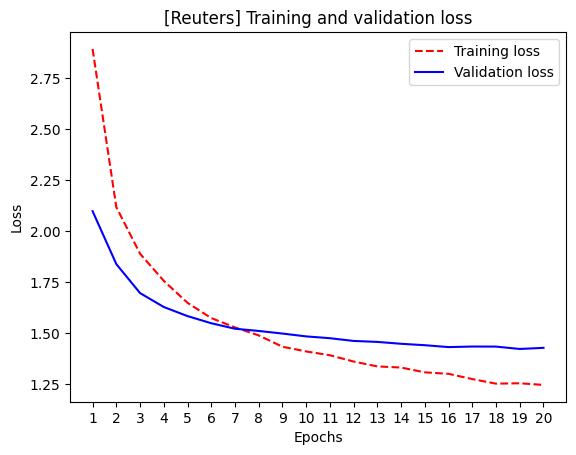

In [190]:
#Plotting the training and validation loss

import matplotlib.pyplot as plt

history_dict = history.history
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']
epochs = range(1, len(loss_values) + 1)

plt.plot(epochs, loss_values, 'r--', label = 'Training loss')
plt.plot(epochs, val_loss_values, 'b', label = 'Validation loss')
plt.title('[Reuters] Training and validation loss')
plt.xlabel('Epochs')
plt.xticks(epochs)
plt.ylabel('Loss')
plt.legend()
plt.show()


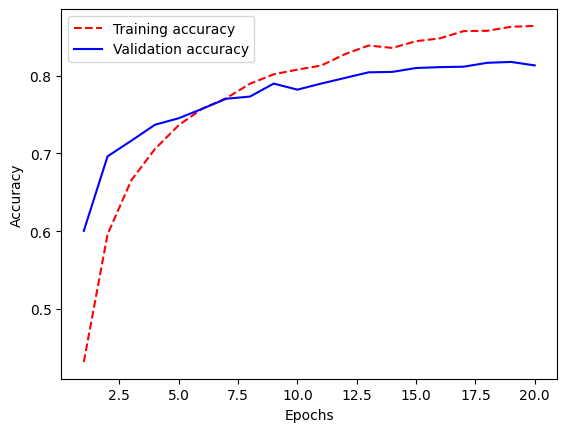

In [191]:
#Plotting the training and validation accuracy

plt.clf()
acc = history_dict['accuracy']
val_acc = history_dict['val_accuracy']
plt.plot(epochs, acc, 'r--', label = 'Training accuracy')
plt.plot(epochs, val_acc, 'b', label = 'Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [192]:
loss, accuracy, top3 = model.evaluate(X_test, y_test)
print(f'Test accuracy: {accuracy:.4f}')
print(f'Top 3 acc: {top3:.4f}')

71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7894 - loss: 1.5069 - top_3_acc: 0.8923
Test accuracy: 0.7894
Top 3 acc: 0.8923


```Another approach: use Embedding instead of multihot```

In [240]:
(train_data, train_labels), (test_data, test_labels) = reuters.load_data(num_words = 20000)

In [241]:
max_length = 500

X_train = keras.preprocessing.sequence.pad_sequences(
    train_data, maxlen = max_length
)

X_test = keras.preprocessing.sequence.pad_sequences(
    test_data, maxlen=max_length
)

from keras.utils import to_categorical

train_labels = to_categorical(train_labels)
test_labels = to_categorical(test_labels)



In [242]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    train_labels,
    test_size=0.2,
    random_state=42
)

y_test = test_labels

In [243]:
model2 = keras.Sequential([
    
    layers.Embedding(
        input_dim=20000,
        output_dim=64,
        input_length=max_length
    ),
    layers.Conv1D(filters=64, kernel_size=5, activation='relu'),    
    layers.Conv1D(filters=64, kernel_size=3, activation='relu'),
    layers.GlobalMaxPooling1D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(46, activation="softmax")
])

In [244]:
model2.compile(
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=0.001,
        weight_decay=1e-4
    ),
    loss= keras.losses.CategoricalCrossentropy(
        label_smoothing=0.1
    ),
    metrics=["accuracy"]
)

In [245]:

history = model2.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=128,
    validation_data=(X_val, y_val),
)

Epoch 1/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - accuracy: 0.3397 - loss: 2.9093 - val_accuracy: 0.4841 - val_loss: 2.3703
Epoch 2/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.4874 - loss: 2.3505 - val_accuracy: 0.5231 - val_loss: 2.1631
Epoch 3/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - accuracy: 0.5331 - loss: 2.1725 - val_accuracy: 0.5771 - val_loss: 2.0553
Epoch 4/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 78ms/step - accuracy: 0.5834 - loss: 2.0339 - val_accuracy: 0.6016 - val_loss: 1.9922
Epoch 5/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - accuracy: 0.6241 - loss: 1.9150 - val_accuracy: 0.6171 - val_loss: 1.9455
Epoch 6/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - accuracy: 0.6572 - loss: 1.8238 - val_accuracy: 0.6405 - val_loss: 1.8803
Epoch 7/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 79ms/step - accuracy: 0.6792 - loss: 1.7518 - val_accuracy: 0.6733 - val_loss: 1.8650
Epoch 8/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 78ms/step - accuracy: 0.7022 - loss: 1.6880 - val_accuracy: 0.6784 - v

In [246]:
loss, accuracy = model2.evaluate(X_test, y_test)
print(f'Test accuracy: {accuracy:.4f}')


71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7462 - loss: 1.6748
Test accuracy: 0.7462
